## Fake News Detection using NLP and ML


### Step 1: Import Necessary Libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re
import seaborn as sns
import string
import warnings
from typing import Dict, Optional

# NLTK
import nltk
from nltk.corpus import stopwords

# Scikit-Learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

### Step 2: Suppress Warnings and Download Required NLTK Resources

In [2]:
# Suppress warning messages during model training.
warnings.filterwarnings('ignore')

# Download required NLTK resources safely
for resource in ['punkt', 'punkt_tab', 'stopwords']:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

### Step 3: Clean Text Function

In [3]:
stop_words = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()                                                   # Converts text to lowercase
    text = re.sub(r'https?://\S+|www\.\S+', '', text)                     # Removes URLs
    text = re.sub(r'<.*?>+', '', text)                                    # Removes HTML tags
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)      # Removes punctuation
    text = re.sub(r'\n', ' ', text)                                       # Removes newlines
    text = re.sub(r'\w*\d\w*', '', text)                                  # Removes numbers
    words = text.split()                                                  # Splits text into words
    words = [w for w in words if w not in stop_words and len(w) > 2]      # Removes stopwords and short words
    return " ".join(words)                                                # Joins words back into text

### Step 4: Load and Explore the Dataset

In [4]:
true_df = pd.read_csv('dataset/True.csv')                          # Loads True news dataset
false_df = pd.read_csv('dataset/Fake.csv')                         # Loads Fake news dataset

true_df['label'] = 1                                               # Assigns label 1 to True news
false_df['label'] = 0                                              # Assigns label 0 to Fake news

data = pd.concat([true_df, false_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)       # Concatenates and shuffles the dataset
data = data.dropna(subset=['text', 'title']).copy()                                                        # Removes rows with missing values in text or title
data['full_content'] = data['title'].fillna('') + " " + data['text'].fillna('')                            # Concatenates title and text
data['cleaned_content'] = data['full_content'].apply(clean_text)                                           # Cleans the text

In [5]:
# True dataset
true_df.head()

,title,text,subject,date,label
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [6]:
# Fake dataset
false_df.head()

,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",0


In [7]:
# Complete dataset
data.head()

,title,text,subject,date,label,full_content,cleaned_content
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",News,"July 21, 2017",0,BREAKING: GOP Chairman Grassley Has Had Enoug...,breaking gop chairman grassley enough demands ...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,News,"May 7, 2016",0,Failed GOP Candidates Remembered In Hilarious...,failed gop candidates remembered hilarious moc...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,News,"December 3, 2016",0,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,mike pence’s new neighbors hilariously trollin...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,politicsNews,"October 6, 2017",1,California AG pledges to defend birth control ...,california pledges defend birth control insura...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,politics,"Apr 25, 2017",0,AZ RANCHERS Living On US-Mexico Border Destroy...,ranchers living usmexico border destroy nancy ...


### Step 5: Feature Extraction (TF-IDF)

In [8]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))              # Creates a TF-IDF vectorizer
X = tfidf_vectorizer.fit_transform(data['cleaned_content'])                            # Transforms the text data into TF-IDF vectors
y = data['label'].values                                                               # Extracts the labels

### Step 6: Split Data into Training and Testing Sets

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display the shapes of training and testing data
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (35918, 5000)
X_test shape: (8980, 5000)
y_train shape: (35918,)
y_test shape: (8980,)


### Step 7: Model Training & Evaluation Function


In [33]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Train the model
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    confusion = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        confusion,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Fake', 'True'],
        yticklabels=['Fake', 'True']
    )
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {model.__class__.__name__}')
    plt.show()

    return accuracy, precision, recall, f1

### Step 8: Train Models

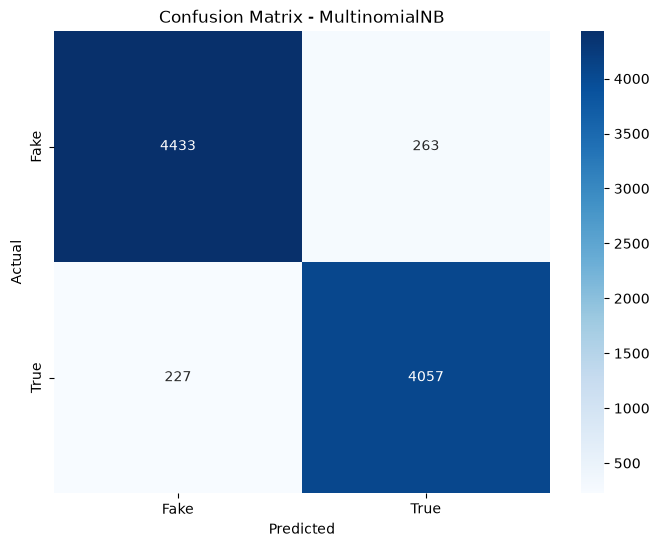

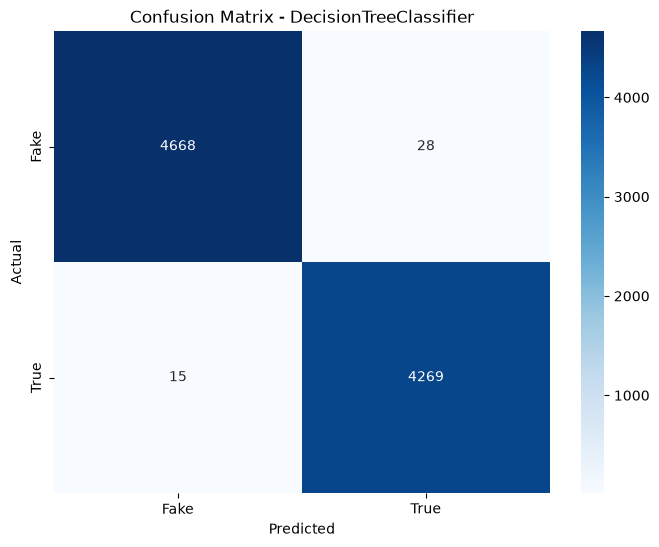

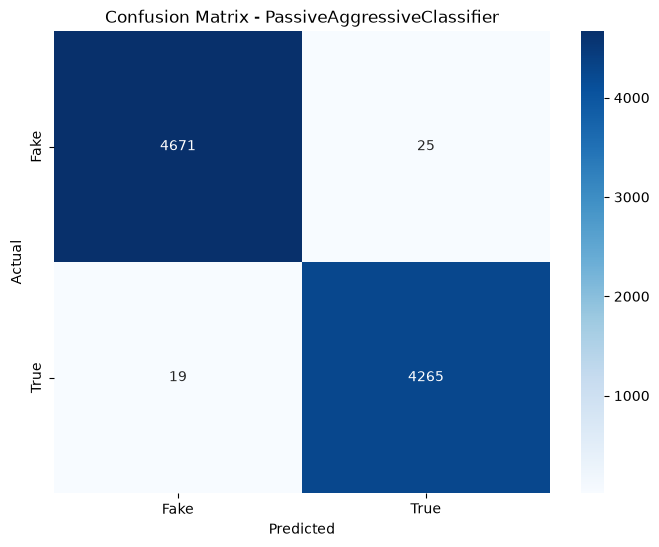

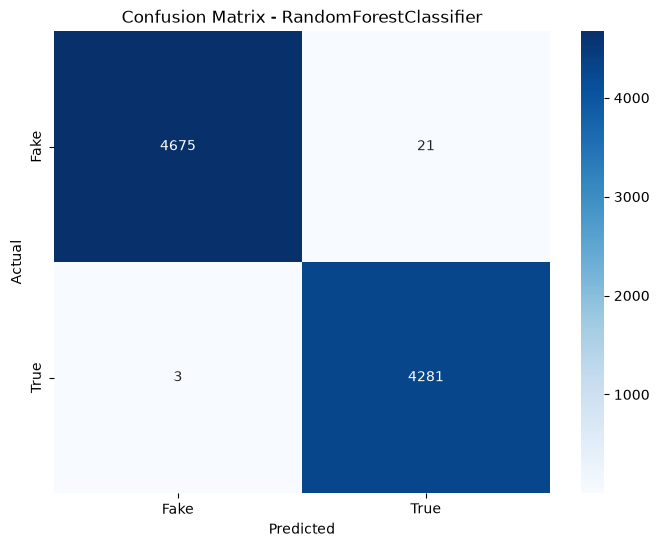

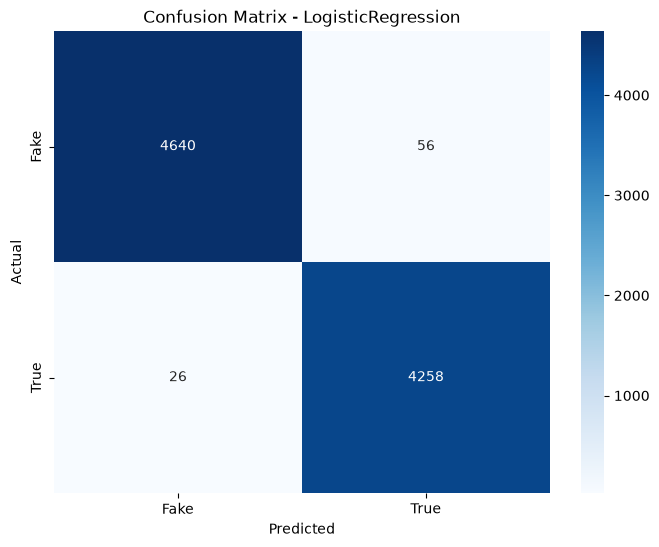

In [39]:
# Initialize and train the Multinomial Naive Bayes model
naive_bayes_model = MultinomialNB()
nb_accuracy, nb_precision, nb_recall, nb_f1 = evaluate_model(naive_bayes_model, X_train, y_train, X_test, y_test)

# Define and train the Decision Tree model
decision_tree = DecisionTreeClassifier()
dt_accuracy, dt_precision, dt_recall, dt_f1 = evaluate_model(decision_tree, X_train, y_train, X_test, y_test)

# Define and train the Passive Aggressive Classifier model
passive_aggressive = PassiveAggressiveClassifier()
pa_accuracy, pa_precision, pa_recall, pa_f1 = evaluate_model(passive_aggressive, X_train, y_train, X_test, y_test)

# Define and train the Random Forest model
random_forest = RandomForestClassifier(n_estimators=100)
rf_accuracy, rf_precision, rf_recall, rf_f1 = evaluate_model(random_forest, X_train, y_train, X_test, y_test)

# Define and train the Logistic Regression model
logistic_regression = LogisticRegression()
lr_accuracy, lr_precision, lr_recall, lr_f1 = evaluate_model(logistic_regression, X_train, y_train, X_test, y_test)

### Step 9: Compare and Plot Model Scores

In [47]:
# Define the algorithm names and their corresponding metrics
algorithms = ['Multinomial Naive Bayes', 'Logistic Regression', 'Random Forest', 'Passive Aggressive', 'Decision Tree']
accuracies = [nb_accuracy, lr_accuracy, rf_accuracy, pa_accuracy, dt_accuracy]
precisions = [nb_precision, lr_precision, rf_precision, pa_precision, dt_precision]
recalls = [nb_recall, lr_recall, rf_recall, pa_recall, dt_recall]
f1_scores = [nb_f1, lr_f1, rf_f1, pa_f1, dt_f1]

results = pd.DataFrame({
    'Algorithm': algorithms,
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
})

print(results.to_string(index=False))

              Algorithm  Accuracy  Precision   Recall  F1 Score
Multinomial Naive Bayes  0.945434   0.945483 0.945434  0.945443
    Logistic Regression  0.990869   0.990893 0.990869  0.990870
          Random Forest  0.997327   0.997336 0.997327  0.997328
     Passive Aggressive  0.995100   0.995101 0.995100  0.995100
          Decision Tree  0.995212   0.995216 0.995212  0.995212


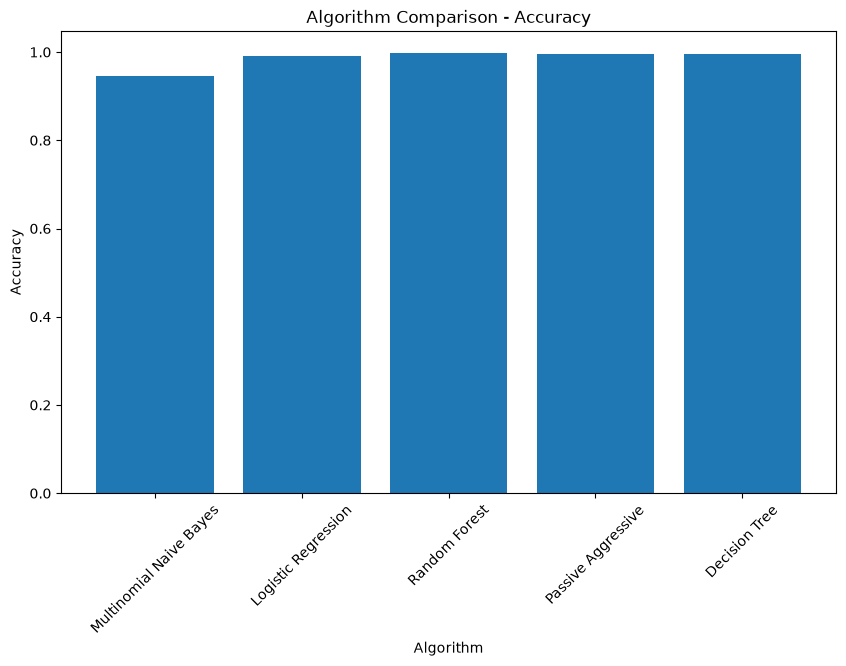

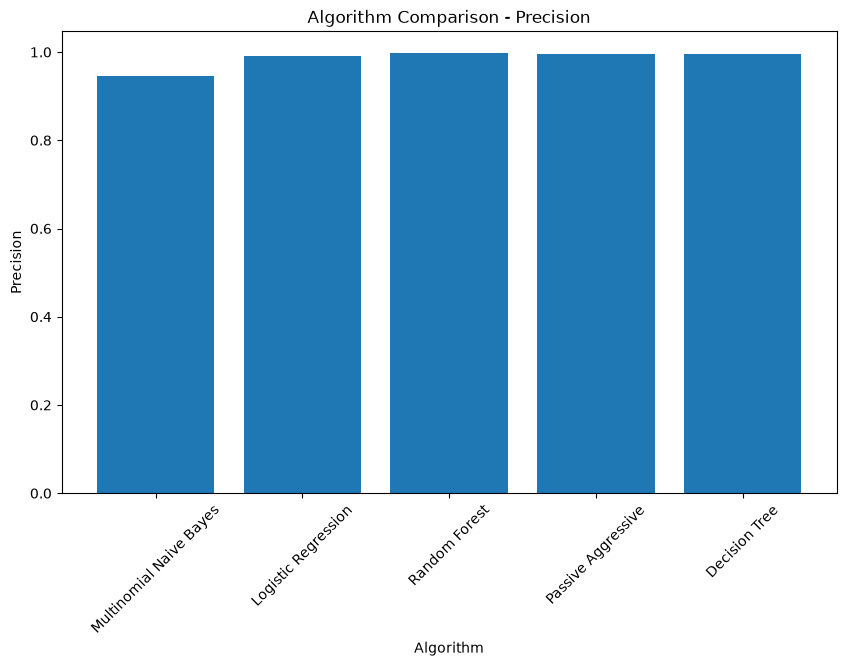

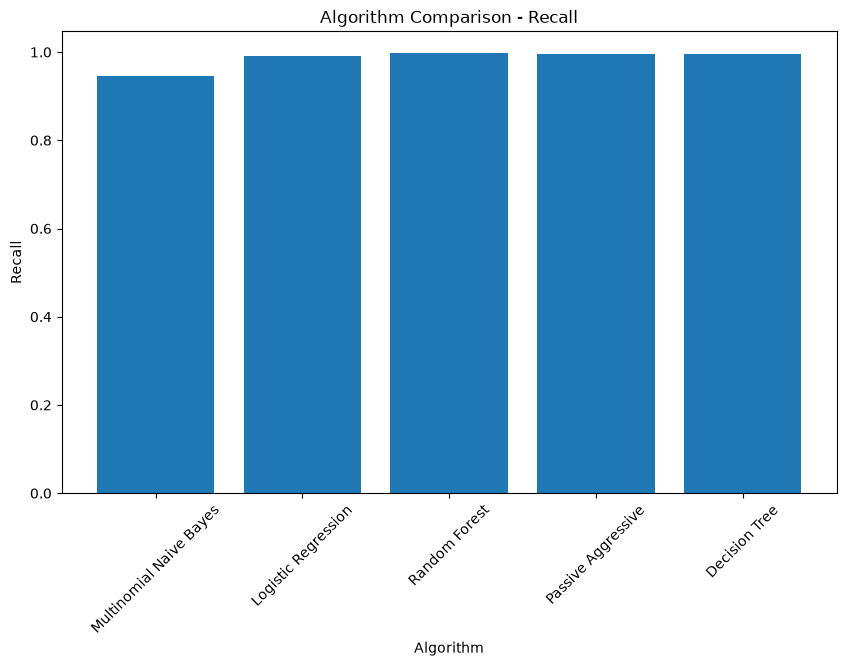

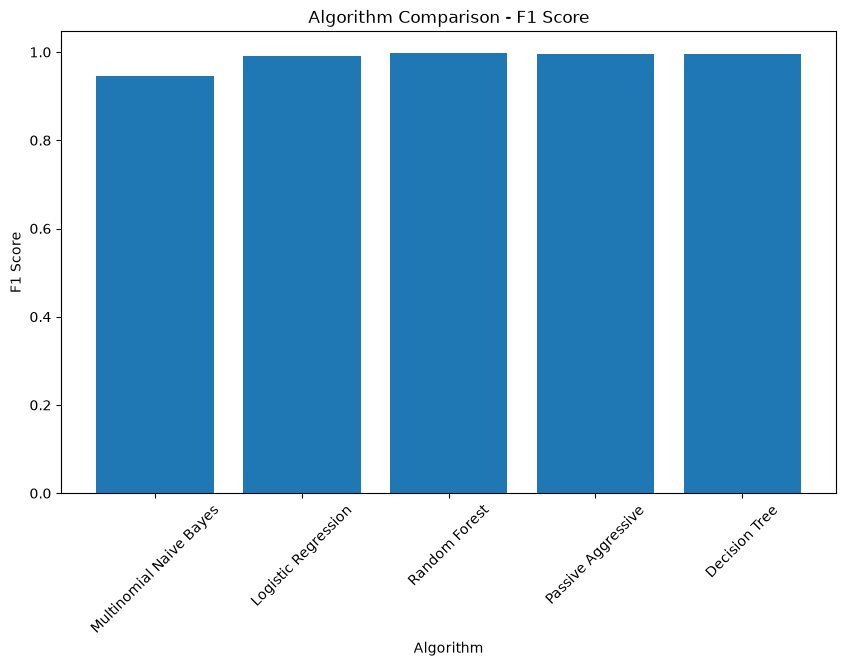

In [48]:
metrics = {
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
}

for metric, values in metrics.items():
    plt.figure(figsize=(10, 6))
    plt.bar(algorithms, values)
    plt.xlabel('Algorithm')
    plt.ylabel(metric)
    plt.title(f'Algorithm Comparison - {metric}')
    plt.xticks(rotation=45)
    plt.show()

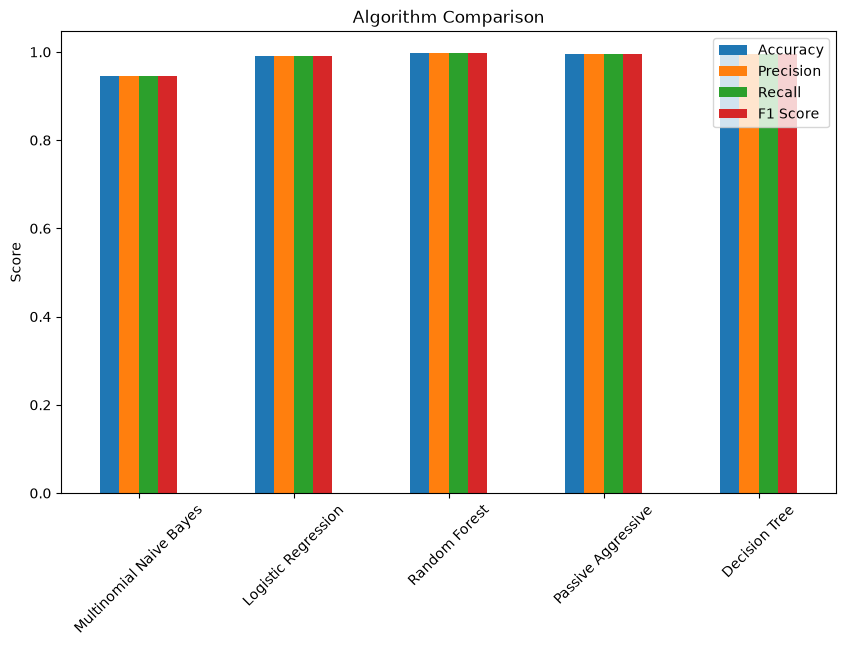

In [52]:
results_df = pd.DataFrame({
    'Accuracy': accuracies,
    'Precision': precisions,
    'Recall': recalls,
    'F1 Score': f1_scores
}, index=algorithms)

results_df.plot(kind='bar', figsize=(10, 6))
plt.ylabel('Score')
plt.title('Algorithm Comparison')
plt.xticks(rotation=45)
plt.legend()
plt.show()

### **Step 10: MODEL VALIDATION**

In [ ]:
import nltk
from nltk.corpus import stopwords

# Define a function for predicting titles
def predict_title(title_text):
    # Preprocess the title
    preprocessed_title_text = title_text.lower()
    preprocessed_title_text = nltk.word_tokenize(preprocessed_title_text)
    preprocessed_title_text = [word for word in preprocessed_title_text if word not in stop_words]

    # Convert the preprocessed text into TF-IDF vectors
    tfidf_vector = tfidf_vectorizer.transform([" ".join(preprocessed_title_text)])

    # Make the prediction
    prediction = naive_bayes_model.predict(tfidf_vector)

    return prediction

# Example titles
title_text_1 = "Donald Trump Sends Out Embarrassing New Year"
title_text_2 = "As U.S. budget fight looms, Republicans flip their fiscal script"

# Predict and display results for both titles
prediction_1 = predict_title(title_text_1)
prediction_2 = predict_title(title_text_2)

print(prediction_1)

if prediction_1 == 1:
    print("Title 1: The news is likely true.")
else:
    print("Title 1: The news is likely fake.")

if prediction_2 == 1:
    print("Title 2: The news is likely true.")
else:
    print("Title 2: The news is likely fake.")


[0]
Title 1: The news is likely fake.
Title 2: The news is likely true.
